## 📚 Import Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocessing and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report,roc_auc_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB


import warnings
warnings.filterwarnings('ignore')

## 📂 Load Dataset

In [2]:
df = pd.read_csv('heart_disease_risk_2026.csv')

In [3]:
df.head(6)

,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,1,44,Male,117,74,193,57,106,119,112,...,False,Never,2.9,86,5.4,19.8,True,7731,62.9,0
1,2,57,Male,139,94,185,69,110,35,114,...,False,Never,3.0,132,4.3,45.8,True,2629,74.6,1
2,3,29,Male,128,78,197,52,108,157,95,...,False,Current,3.5,128,5.1,17.7,True,9290,65.7,0
3,4,72,Male,132,86,197,59,104,143,92,...,False,Never,2.7,18,6.8,63.6,True,7373,48.5,1
4,5,62,Female,116,75,154,65,75,104,135,...,True,Former,3.3,24,8.2,58.7,False,6331,47.3,1
5,6,50,Female,122,71,147,46,101,41,134,...,True,Former,3.3,190,5.9,55.1,False,6857,82.6,0


In [4]:
df.shape

(9000, 27)

In [5]:
df.describe()

,patient_id,age,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,...,resting_heart_rate,max_heart_rate_achieved,st_depression,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,daily_steps,diet_quality_score,has_heart_disease
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,...,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,4500.500000,53.977333,127.849778,80.788778,188.753556,55.215333,103.275556,152.045000,119.470444,5.791633,...,80.912667,164.838333,1.012911,5.708733,139.493444,6.994578,47.968033,6163.659333,59.467400,0.303000
std,2598.220545,13.008051,13.767233,10.939943,32.271644,12.394400,27.342198,51.448384,22.778082,0.692645,...,8.604685,21.290773,0.957090,5.070642,63.660433,1.104215,16.162484,2170.685995,14.476064,0.459581
min,1.000000,18.000000,85.000000,50.000000,90.000000,18.000000,35.000000,35.000000,60.000000,4.000000,...,48.000000,93.000000,0.000000,0.000000,0.000000,3.100000,0.000000,500.000000,4.800000,0.000000
25%,2250.750000,45.000000,119.000000,74.000000,167.000000,47.000000,85.000000,117.000000,104.000000,5.300000,...,75.000000,150.000000,0.400000,2.200000,96.000000,6.300000,37.100000,4658.000000,49.700000,0.000000
50%,4500.500000,54.000000,128.000000,81.000000,189.000000,55.000000,103.000000,151.000000,119.000000,5.800000,...,81.000000,166.000000,0.700000,4.200000,139.000000,7.000000,48.100000,6178.000000,59.600000,0.000000
75%,6750.250000,63.000000,137.000000,88.000000,211.000000,64.000000,122.000000,186.000000,135.000000,6.300000,...,87.000000,180.000000,1.400000,7.700000,183.000000,7.700000,58.900000,7632.750000,69.100000,1.000000
max,9000.000000,90.000000,181.000000,126.000000,314.000000,110.000000,207.000000,390.000000,204.000000,8.600000,...,111.000000,210.000000,6.500000,45.900000,366.000000,11.000000,100.000000,13950.000000,100.000000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 9000 non-null   int64  
 1   age                        9000 non-null   int64  
 2   sex                        9000 non-null   object 
 3   resting_bp_systolic        9000 non-null   int64  
 4   resting_bp_diastolic       9000 non-null   int64  
 5   cholesterol_total          9000 non-null   int64  
 6   hdl                        9000 non-null   int64  
 7   ldl                        9000 non-null   int64  
 8   triglycerides              9000 non-null   int64  
 9   fasting_blood_sugar        9000 non-null   int64  
 10  hba1c                      9000 non-null   float64
 11  bmi                        9000 non-null   float64
 12  resting_heart_rate         9000 non-null   int64  
 13  max_heart_rate_achieved    9000 non-null   int64

## 🧹 Data Preprocessing

In [7]:
df.isnull().sum()

patient_id                   0
age                          0
sex                          0
resting_bp_systolic          0
resting_bp_diastolic         0
cholesterol_total            0
hdl                          0
ldl                          0
triglycerides                0
fasting_blood_sugar          0
hba1c                        0
bmi                          0
resting_heart_rate           0
max_heart_rate_achieved      0
chest_pain_type              0
exercise_induced_angina      0
st_depression                0
family_history               0
smoker_status                0
alcohol_units_per_week       0
exercise_minutes_per_week    0
sleep_hours                  0
stress_score                 0
wearable_owner               0
daily_steps                  0
diet_quality_score           0
has_heart_disease            0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
# Outlier Treatment using IQR for numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] > upper_bound, upper_bound,
                       np.where(df[col] < lower_bound, lower_bound, df[col]))

# Feature Scaling - StandardScaler
ss = StandardScaler()
df_standard_scaled = df.copy()
df_standard_scaled[num_cols] = ss.fit_transform(df[num_cols])

# Feature Scaling - MinMaxScaler
mm = MinMaxScaler()
df_minmax_scaled = df.copy()
df_minmax_scaled[num_cols] = mm.fit_transform(df[num_cols])

## 📊 Exploratory Data Analysis (EDA)

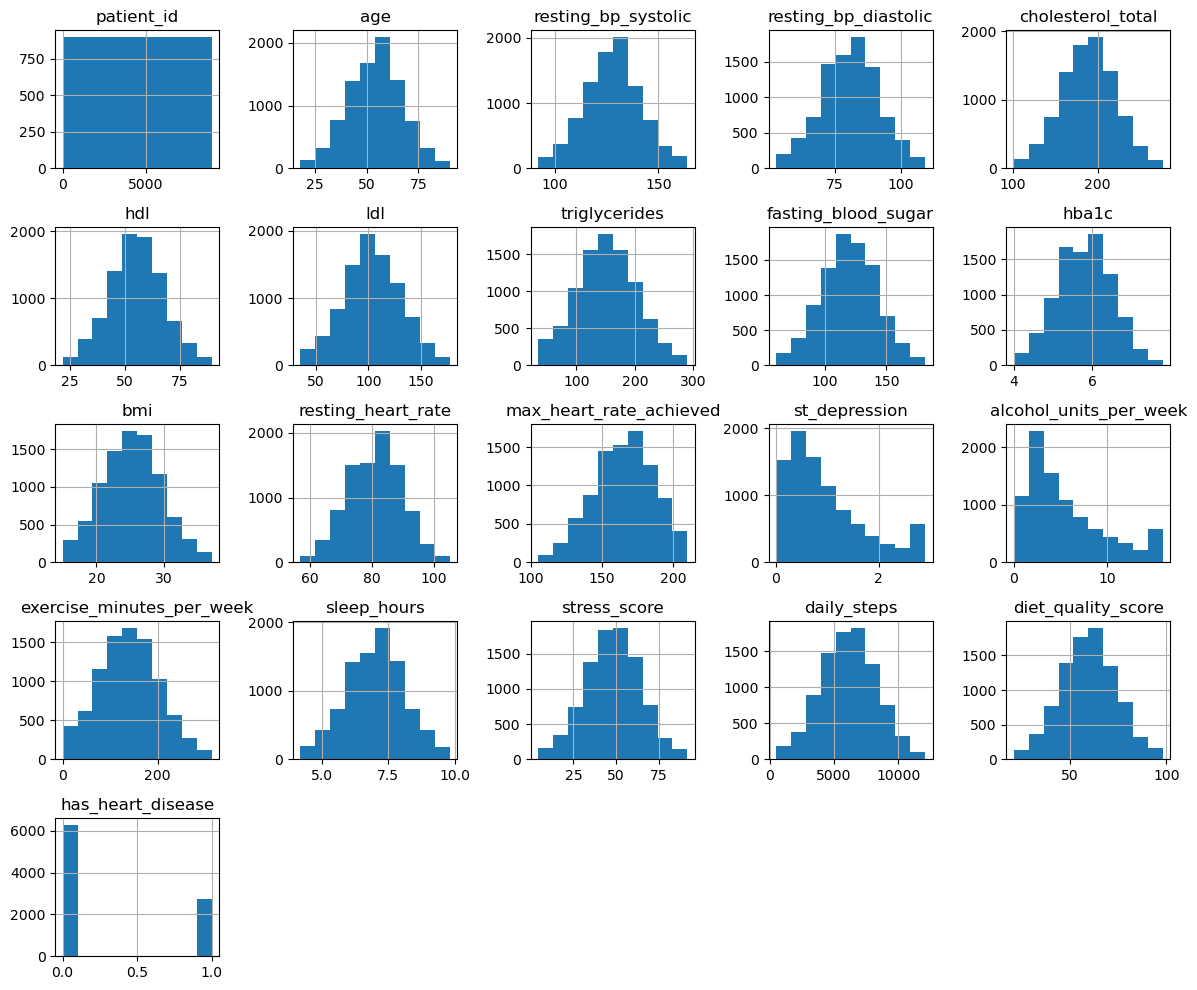

In [11]:
# Histogram
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

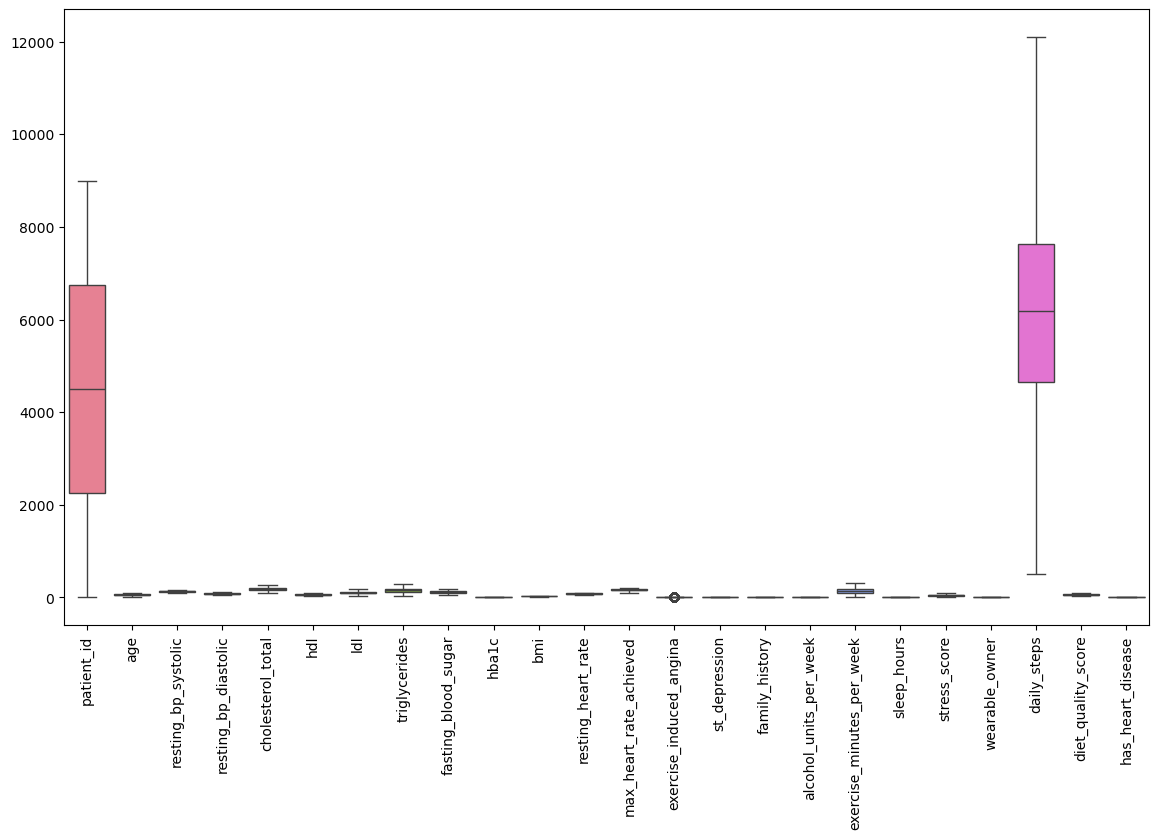

In [12]:
# Box Plot
plt.figure(figsize=(14, 8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

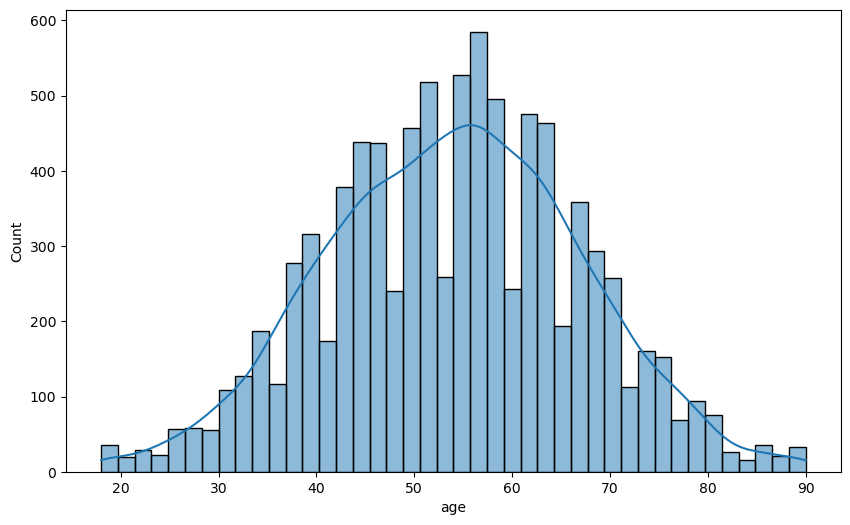

In [13]:
# Distribution Plot
plt.figure(figsize=(10, 6))
sns.histplot(df["age"], kde=True)
plt.show()

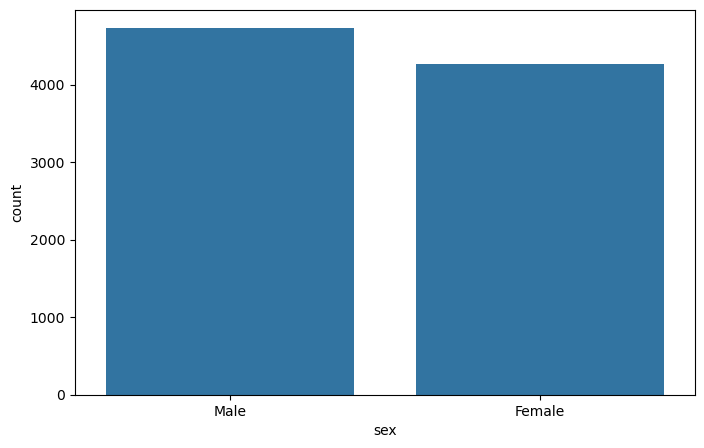

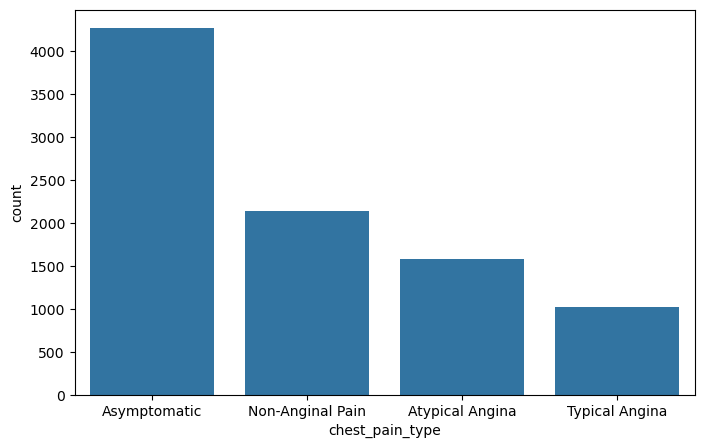

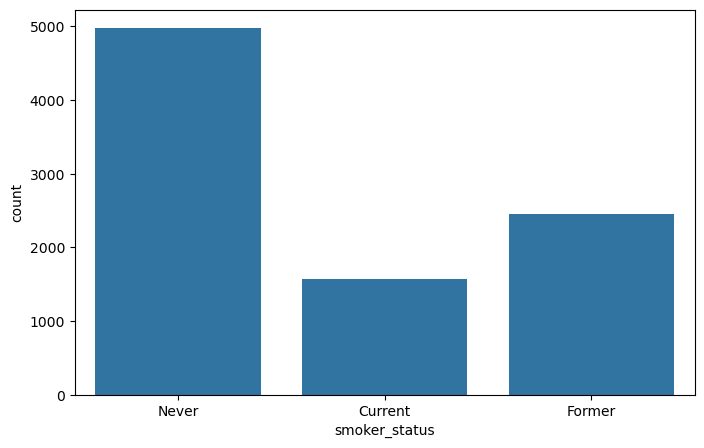

In [14]:
# Count Plot (for categorical columns)
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, data=df)
    plt.show()

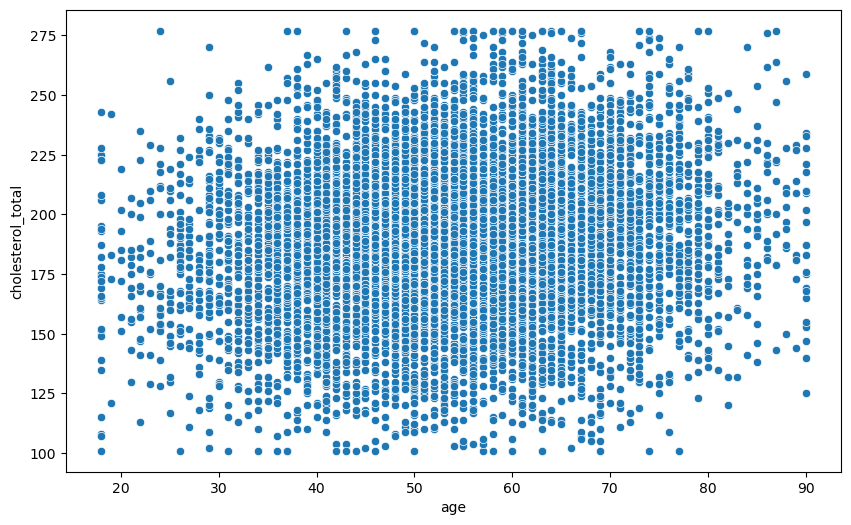

In [15]:
# Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x="age", y="cholesterol_total", data=df)
plt.show()


In [16]:
# # Pair Plot
# sns.pairplot(df)
# plt.show()

## Creating New Features & Removing Unnecessary Columns 

In [17]:
df = df.drop(columns=["patient_id"])

In [18]:
df["cholesterol_hdl_ratio"] = (df["cholesterol_total"] / df["hdl"])

In [19]:
df_numeric = df.select_dtypes(include=[np.number])
correlation = df_numeric.corr()
top_features = (correlation["has_heart_disease"].abs().nlargest(10).index)
print(top_features)

Index(['has_heart_disease', 'max_heart_rate_achieved', 'cholesterol_hdl_ratio',
       'st_depression', 'age', 'ldl', 'hdl', 'exercise_minutes_per_week',
       'resting_bp_systolic', 'hba1c'],
      dtype='object')


In [20]:
pd.get_dummies(df, columns=['sex'])

,age,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,bmi,...,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease,cholesterol_hdl_ratio,sex_Female,sex_Male
0,44.0,117.0,74.0,193.0,57.0,106.0,119.0,112.0,5.2,26.5,...,86.0,5.4,19.8,True,7731.0,62.9,0.0,3.385965,False,True
1,57.0,139.0,94.0,185.0,69.0,110.0,35.0,114.0,5.9,20.8,...,132.0,4.3,45.8,True,2629.0,74.6,1.0,2.681159,False,True
2,29.0,128.0,78.0,197.0,52.0,108.0,157.0,95.0,5.5,24.5,...,128.0,5.1,17.7,True,9290.0,65.7,0.0,3.788462,False,True
3,72.0,132.0,86.0,197.0,59.0,104.0,143.0,92.0,4.8,27.3,...,18.0,6.8,63.6,True,7373.0,48.5,1.0,3.338983,False,True
4,62.0,116.0,75.0,154.0,65.0,75.0,104.0,135.0,6.2,26.0,...,24.0,8.2,58.7,False,6331.0,47.3,1.0,2.369231,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,36.0,108.0,63.0,178.0,68.0,82.0,158.0,96.0,5.3,25.1,...,306.0,8.6,51.1,False,7144.0,58.1,0.0,2.617647,True,False
8996,44.0,112.0,73.0,213.0,54.0,139.0,102.0,125.0,5.9,23.6,...,76.0,6.5,37.1,False,7395.0,68.9,0.0,3.944444,True,False
8997,57.0,144.0,93.0,198.0,66.0,113.0,79.0,102.0,5.7,28.2,...,194.0,6.2,46.3,False,7424.0,70.2,0.0,3.000000,True,False
8998,61.0,130.0,70.0,220.0,68.0,135.0,109.0,104.0,5.5,27.5,...,139.0,5.0,66.5,False,5716.0,43.8,1.0,3.235294,True,False


In [21]:
df = pd.get_dummies(df, columns=['sex'])

In [22]:
df = pd.get_dummies(df, columns=["chest_pain_type"])

In [23]:
df = pd.get_dummies(df, columns=["smoker_status"])

In [24]:
df.select_dtypes(include=['object']).columns

Index([], dtype='object')

##  Model Training

### Train and Test, Split

In [25]:
X = df.drop(columns=["has_heart_disease"])
y = df["has_heart_disease"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
gnb = GaussianNB()
rfc = RandomForestClassifier(n_estimators=50, random_state=2)

In [28]:
clfs = {
    'SVC.................' : svc,
    'KN..................' : knc, 
    'DT..................' : dtc, 
    'LR..................' : lrc, 
    'GNB.................' : gnb,
    'RF..................' : rfc
}

In [29]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    auc = roc_auc_score(y_test,y_pred)
    confusion = confusion_matrix(y_test,y_pred)
    
    return accuracy,precision,recall,f1,auc,confusion

In [30]:
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
auc_scores =[]
confusion = []


for name,clf in clfs.items():
    
    current_accuracy,current_precision,current_recall, current_f1 , current_roc_auc_score, current_confution_matrix = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    print("Recall - ", current_recall)
    print("F1 - ", current_f1)
    print("Roc_auc - ",current_roc_auc_score)
    print("confusion_matrix - ")
    print(current_confution_matrix)


    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)
    recall_scores.append(current_recall)
    f1_scores.append(current_f1)
    auc_scores.append(current_roc_auc_score)
    confusion.append(current_confution_matrix)

For  SVC.................
Accuracy -  0.6911111111111111
Precision -  0.0
Recall -  0.0
F1 -  0.0
Roc_auc -  0.5
confusion_matrix - 
[[1244    0]
 [ 556    0]]
For  KN..................
Accuracy -  0.7472222222222222
Precision -  0.6463768115942029
Recall -  0.4010791366906475
F1 -  0.49500554938956715
Roc_auc -  0.6515041985704041
confusion_matrix - 
[[1122  122]
 [ 333  223]]
For  DT..................
Accuracy -  0.8605555555555555
Precision -  0.8157349896480331
Recall -  0.7086330935251799
F1 -  0.7584215591915303
Roc_auc -  0.8185448425825257
confusion_matrix - 
[[1155   89]
 [ 162  394]]
For  LR..................
Accuracy -  0.9072222222222223
Precision -  0.8635514018691589
Recall -  0.8309352517985612
F1 -  0.846929422548121
Roc_auc -  0.8861267898864189
confusion_matrix - 
[[1171   73]
 [  94  462]]
For  GNB.................
Accuracy -  0.8611111111111112
Precision -  0.7533112582781457
Recall -  0.8183453237410072
F1 -  0.7844827586206896
Roc_auc -  0.8492852020634297
confusi

## Model Comparison

In [31]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores, 'Recall':recall_scores,
                               'F1':f1_scores, 'ROC':auc_scores}).sort_values('Precision',ascending=False)

In [32]:
performance_df

,Algorithm,Accuracy,Precision,Recall,F1,ROC
3,LR..................,0.907222,0.863551,0.830935,0.846929,0.886127
5,RF..................,0.875000,0.841237,0.733813,0.783862,0.835958
2,DT..................,0.860556,0.815735,0.708633,0.758422,0.818545
4,GNB.................,0.861111,0.753311,0.818345,0.784483,0.849285
1,KN..................,0.747222,0.646377,0.401079,0.495006,0.651504
0,SVC.................,0.691111,0.000000,0.000000,0.000000,0.500000


In [34]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [35]:
performance_df1

,Algorithm,variable,value
0,LR..................,Accuracy,0.907222
1,RF..................,Accuracy,0.875000
2,DT..................,Accuracy,0.860556
3,GNB.................,Accuracy,0.861111
4,KN..................,Accuracy,0.747222
5,SVC.................,Accuracy,0.691111
6,LR..................,Precision,0.863551
7,RF..................,Precision,0.841237
8,DT..................,Precision,0.815735
9,GNB.................,Precision,0.753311


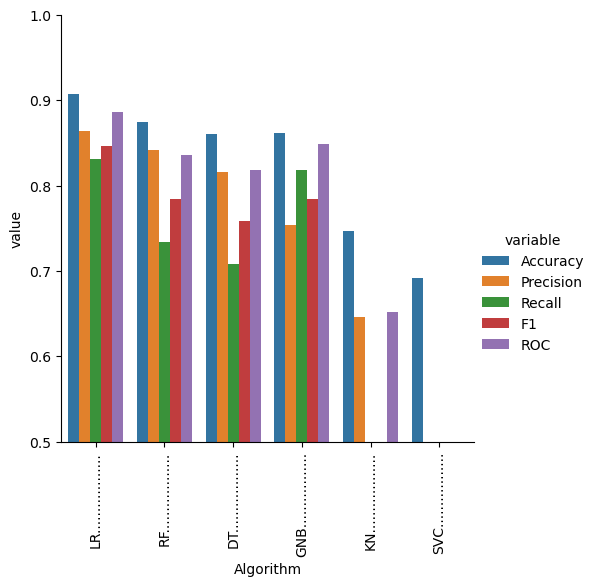

In [36]:
sns.catplot(x = 'Algorithm', y='value', hue = 'variable', data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [37]:
import joblib
joblib.dump(lrc,'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Logistic Regression Model and Scaler successfully saved!")

Logistic Regression Model and Scaler successfully saved!
